CONTENTS:
- [Load Outcomes](#load-outcomes)
- [Analyze Results](#analyze-results)
  - [Evaluate Using AC Score](#evaluate-using-our-metric)
  - [Evaluate Vertical Volatility](#vertical-volatility)
  - [Examine One-Step-Ahead Forecasts](#examine-one-step-ahead-forecasts)
- [Visualizations](#visualizations)
  - [Tabular View](#tabular-view)

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from pathlib import Path
import os
from matplotlib.ticker import FormatStrFormatter

In [3]:
import logging

import helpers.hdbg as hdbg

hdbg.init_logger(verbosity=logging.INFO)
_LOG = logging.getLogger(__name__)

INFO  > cmd='C:\Users\Chutian\anaconda3\envs\nn\Lib\site-packages\ipykernel_launcher.py -f C:\Users\Chutian\AppData\Roaming\jupyter\runtime\kernel-02351be5-8023-4b4a-890a-93da362ac8e2.json'


<a name='load-outcomes'></a>
# Load Outcomes

In [4]:
outcomes_dir = "./outcomes/2026_01_27_linear"
forecast_ensembles = []
metrics = []
model_configs = []
for filename in os.listdir(outcomes_dir):
    if filename.startswith('id_to_forecast_ensembles') and filename.endswith('.pt'):
        filepath = os.path.join(outcomes_dir, filename)
        data = torch.load(filepath, weights_only = False)
        forecast_ensembles.append(data)
    if filename.startswith('id_to_metrics') and filename.endswith('.pt'):
        filepath = os.path.join(outcomes_dir, filename)
        data = torch.load(filepath, weights_only = False)
        metrics.append(data)
    if filename.startswith('id_to_model_configs') and filename.endswith('.pt'):
        filepath = os.path.join(outcomes_dir, filename)
        data = torch.load(filepath, weights_only = False)
        model_configs.append(data)
print(f"Loaded {len(forecast_ensembles)} forecast ensemble files.")
print(f"Loaded {len(metrics)} metric files.")
print(f"Loaded {len(model_configs)} model config files.")

Loaded 138 forecast ensemble files.
Loaded 138 metric files.
Loaded 138 model config files.


In [5]:
id_to_forecast_ensembles = dict()
for partial_outcome in forecast_ensembles:
    id_to_forecast_ensembles.update(partial_outcome)
id_to_metrics = dict()
for partial_outcome in metrics:
    id_to_metrics.update(partial_outcome)
id_to_model_configs = dict()
for partial_outcome in model_configs:
    id_to_model_configs.update(partial_outcome)

In [6]:
all_ids = list(id_to_metrics.keys())

<a name='analyze-results'></a>
# Analyze Results

<a name='evaluate-using-our-metric'></a>
## Evaluate Using AC Score

In [7]:
# Default train scores.
loss_default_train = [id_to_metrics[key]['default_train']['loss'].item() for key in id_to_metrics.keys()]
acc_default_train = [id_to_metrics[key]['default_train']['accuracy_score'].item() for key in id_to_metrics.keys()]
stb_default_train = [id_to_metrics[key]['default_train']['stability_score'].item() for key in id_to_metrics.keys()]
# Default validate scores.
loss_default_validate = [id_to_metrics[key]['default_validate']['loss'].item() for key in id_to_metrics.keys()]
acc_default_validate = [id_to_metrics[key]['default_validate']['accuracy_score'].item() for key in id_to_metrics.keys()]
stb_default_validate = [id_to_metrics[key]['default_validate']['stability_score'].item() for key in id_to_metrics.keys()]
# Custom train scores.
loss_custom_train = [
    pd.Series(id_to_metrics[key]['custom_train']["loss_history"][-50:]).mean()
    for key in id_to_metrics.keys()
]
# Custom validate scores.
loss_custom_validate = [id_to_metrics[key]['custom_validate']['loss'].item() for key in id_to_metrics.keys()]
acc_custom_validate = [id_to_metrics[key]['custom_validate']['accuracy_score'].item() for key in id_to_metrics.keys()]
stb_custom_validate = [id_to_metrics[key]['custom_validate']['stability_score'].item() for key in id_to_metrics.keys()]
# Record ids.
ids = list(id_to_metrics.keys())

In [8]:
loss_df = pd.DataFrame({
    "loss_default_train": loss_default_train,
    "acc_default_train": acc_default_train,
    "stb_default_train": stb_default_train,
    "loss_default_validate": loss_default_validate,
    "acc_default_validate": acc_default_validate,
    "stb_default_validate": stb_default_validate,
    "loss_custom_train": loss_custom_train,
    "loss_custom_validate": loss_custom_validate,
    "acc_custom_validate": acc_custom_validate,
    "stb_custom_validate": stb_custom_validate,
    "ids": ids,
})

In [9]:
# Compute relative improvements.
loss_df["loss_impr_validate"] = (loss_df["loss_default_validate"] - loss_df["loss_custom_validate"]) / loss_df["loss_default_validate"] * 100
loss_df["acc_impr_validate"] = (loss_df["acc_default_validate"] - loss_df["acc_custom_validate"]) / loss_df["acc_default_validate"] * 100
loss_df["stb_impr_validate"] = (loss_df["stb_default_validate"] - loss_df["stb_custom_validate"]) / loss_df["stb_default_validate"] * 100

In [10]:
loss_df.head(3)

,loss_default_train,acc_default_train,stb_default_train,loss_default_validate,acc_default_validate,stb_default_validate,loss_custom_train,loss_custom_validate,acc_custom_validate,stb_custom_validate,ids,loss_impr_validate,acc_impr_validate,stb_impr_validate
0,210.007241,171.844223,76.326035,210.007241,171.844223,76.326035,137.097928,138.195365,124.645977,27.098777,T000000,34.194952,27.465716,64.496024
1,2578.304029,2257.879966,640.848125,2578.304029,2257.879966,640.848125,2134.055209,2488.852071,2288.309828,401.084486,T000001,3.469411,-1.347718,37.413488
2,885.768315,744.868515,281.799599,885.768315,744.868515,281.799599,978.797490,833.400254,762.274451,142.251606,T000002,5.912162,-2.336780,49.520295


In [13]:
# Percentage improvement in multi-horizon accuracy scores.
loss_df["rel_improv_acc"] = (
    (
        loss_df["acc_default_validate"]
        - loss_df["acc_custom_validate"]
    )
    / loss_df["acc_default_validate"] * 100
)
loss_df["rel_improv_acc"].median()

np.float64(3.18190553541828)

In [14]:
# Percentage improvement in multi-horizon stability scores.
loss_df["rel_improv_stb"] = (
    (
        loss_df["stb_default_validate"]
        - loss_df["stb_custom_validate"]
    )
    / loss_df["stb_default_validate"] * 100
)
loss_df["rel_improv_stb"].median()

np.float64(49.998281487660186)

In [15]:
# Percentage improvement in multi-horizon total scores.
loss_df["rel_improv_AC"] = (
    (
        loss_df["loss_default_validate"]
        - loss_df["loss_custom_validate"]
    )
    / loss_df["loss_default_validate"] * 100
)
loss_df["rel_improv_AC"].median()

np.float64(7.944202681688315)

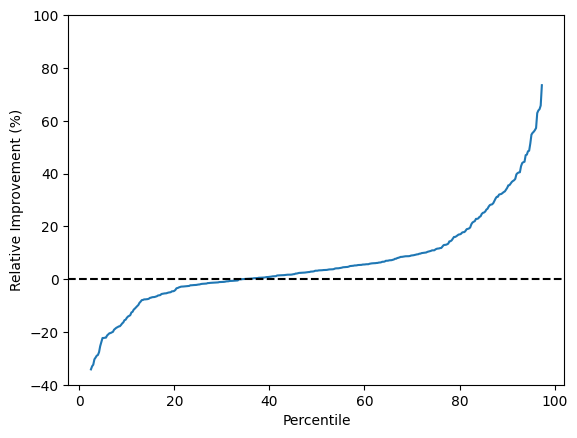

In [16]:
# Plot accuracy score improvement by percentile in ascending order.
perc_improv_ascending_df = pd.DataFrame({"relative_improvement": sorted(loss_df["rel_improv_acc"].dropna())})
perc_improv_ascending_df = perc_improv_ascending_df.reset_index()
perc_improv_ascending_df["index"] = perc_improv_ascending_df["index"] / perc_improv_ascending_df.shape[0] * 100
perc_improv_ascending_df.iloc[10:-10].plot(x="index", y="relative_improvement", legend=False)
plt.axhline(y=0, linestyle="--", color="black")
plt.ylim(-40, 100)
plt.xlabel("Percentile")
plt.ylabel("Relative Improvement (%)")
plt.show()

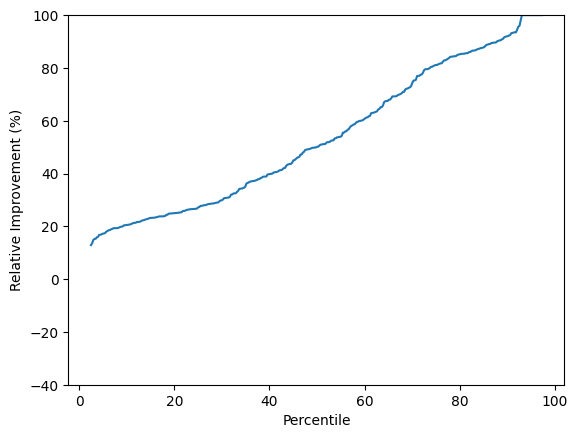

In [17]:
# Plot stability score improvement by percentile in ascending order.
perc_improv_ascending_df = pd.DataFrame({"relative_improvement": sorted(loss_df["rel_improv_stb"].dropna())})
perc_improv_ascending_df = perc_improv_ascending_df.reset_index()
perc_improv_ascending_df["index"] = perc_improv_ascending_df["index"] / perc_improv_ascending_df.shape[0] * 100
perc_improv_ascending_df.iloc[10:-10].plot(x="index", y="relative_improvement", legend=False)
plt.ylim(-40, 100)
plt.xlabel("Percentile")
plt.ylabel("Relative Improvement (%)")
plt.show()

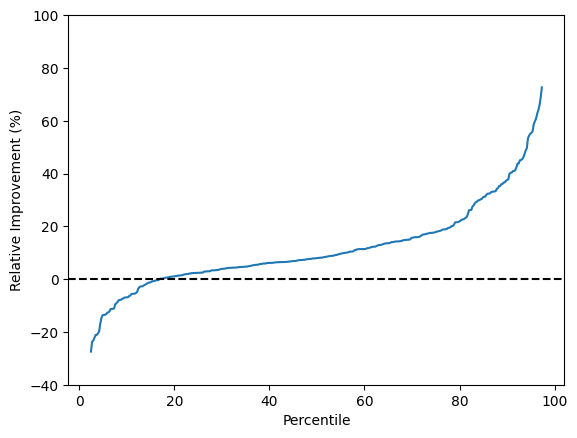

In [18]:
# Plot AC score improvement by percentile in ascending order.
perc_improv_ascending_df = pd.DataFrame({"relative_improvement": sorted(loss_df["rel_improv_AC"].dropna())})
perc_improv_ascending_df = perc_improv_ascending_df.reset_index()
perc_improv_ascending_df["index"] = perc_improv_ascending_df["index"] / perc_improv_ascending_df.shape[0] * 100
perc_improv_ascending_df.iloc[10:-10].plot(x="index", y="relative_improvement", legend=False)
plt.axhline(y=0, linestyle="--", color="black")
plt.ylim(-40, 100)
plt.xlabel("Percentile")
plt.ylabel("Relative Improvement (%)")
plt.show()

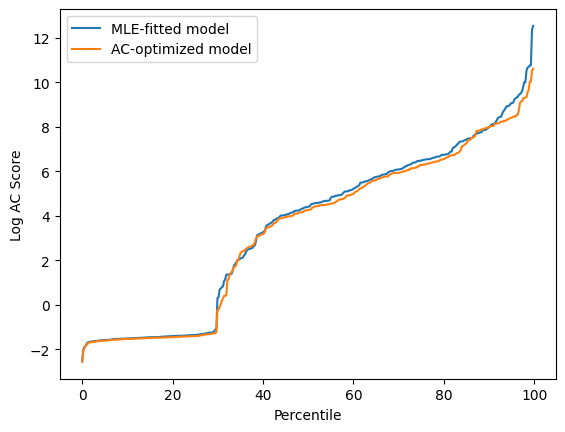

In [19]:
# Plot log scale AC score comparison.
log_loss_df = loss_df[["loss_default_validate", "loss_custom_validate"]].copy()
log_loss_df["log_loss_default_validate"] = np.log(log_loss_df["loss_default_validate"])
log_loss_df["log_loss_custom_validate"] = np.log(log_loss_df["loss_custom_validate"])
_, ax = plt.subplots()
log_loss_default_validate = log_loss_df[["log_loss_default_validate"]].sort_values("log_loss_default_validate").reset_index(drop=True).reset_index()
log_loss_default_validate["index"] = log_loss_default_validate["index"] / log_loss_default_validate.shape[0] * 100
log_loss_default_validate.plot(x="index", y="log_loss_default_validate", ax=ax, label="MLE-fitted model")
log_loss_custom_validate = log_loss_df[["log_loss_custom_validate"]].sort_values("log_loss_custom_validate").reset_index(drop=True).reset_index()
log_loss_custom_validate["index"] = log_loss_custom_validate["index"] / log_loss_custom_validate.shape[0] * 100
log_loss_custom_validate.plot(x="index", y="log_loss_custom_validate", ax=ax, label="AC-optimized model")
plt.xlabel("Percentile")
plt.ylabel("Log AC Score")
plt.show()

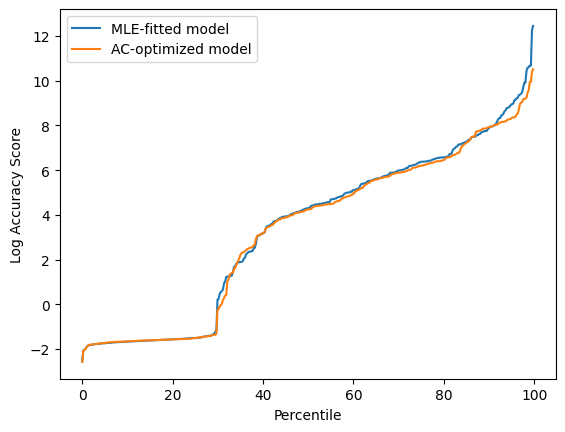

In [20]:
# Plot log scale accuracy score comparison.
log_loss_df = loss_df[["acc_default_validate", "acc_custom_validate"]].copy()
log_loss_df["log_acc_default_validate"] = np.log(log_loss_df["acc_default_validate"])
log_loss_df["log_acc_custom_validate"] = np.log(log_loss_df["acc_custom_validate"])
_, ax = plt.subplots()
log_loss_default_validate = log_loss_df[["log_acc_default_validate"]].sort_values("log_acc_default_validate").reset_index(drop=True).reset_index()
log_loss_default_validate["index"] = log_loss_default_validate["index"] / log_loss_default_validate.shape[0] * 100
log_loss_default_validate.plot(x="index", y="log_acc_default_validate", ax=ax, label="MLE-fitted model")
log_loss_custom_validate = log_loss_df[["log_acc_custom_validate"]].sort_values("log_acc_custom_validate").reset_index(drop=True).reset_index()
log_loss_custom_validate["index"] = log_loss_custom_validate["index"] / log_loss_custom_validate.shape[0] * 100
log_loss_custom_validate.plot(x="index", y="log_acc_custom_validate", ax=ax, label="AC-optimized model")
plt.xlabel("Percentile")
plt.ylabel("Log Accuracy Score")
plt.legend()
plt.show()

C:\Users\Chutian\anaconda3\envs\nn\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
C:\Users\Chutian\anaconda3\envs\nn\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


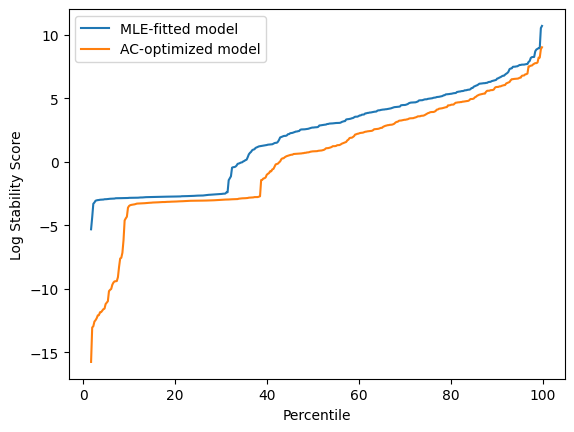

In [21]:
# Plot log scale stability score comparison.
log_loss_df = loss_df[["stb_default_validate", "stb_custom_validate"]].copy()
log_loss_df["log_stb_default_validate"] = np.log(log_loss_df["stb_default_validate"])
log_loss_df["log_stb_custom_validate"] = np.log(log_loss_df["stb_custom_validate"])
_, ax = plt.subplots()
log_loss_default_validate = log_loss_df[["log_stb_default_validate"]].sort_values("log_stb_default_validate").reset_index(drop=True).reset_index()
log_loss_default_validate["index"] = log_loss_default_validate["index"] / log_loss_default_validate.shape[0] * 100
log_loss_default_validate.plot(x="index", y="log_stb_default_validate", ax=ax, label="MLE-fitted model")
log_loss_custom_validate = log_loss_df[["log_stb_custom_validate"]].sort_values("log_stb_custom_validate").reset_index(drop=True).reset_index()
log_loss_custom_validate["index"] = log_loss_custom_validate["index"] / log_loss_custom_validate.shape[0] * 100
log_loss_custom_validate.plot(x="index", y="log_stb_custom_validate", ax=ax, label="AC-optimized model")
plt.xlabel("Percentile")
plt.ylabel("Log Stability Score")
plt.show()

<a name='evaluate-vertical-volatility'></a>
## Evaluate Vertical Volatility

In [22]:
def antidiag_std_mean(arr: np.ndarray) -> float:
    """
    Compute std along each antidiagonal, then average those stds.
    
    :param arr: 2 dimensional data
    :return: average standard deviation along anti-diagonal of data
    """
    flipped = np.flip(arr, axis=1)
    # Get all antidiagonals.
    n_rows, n_cols = arr.shape
    offsets = range(-n_rows + 1, n_cols)
    stds = []
    for k in offsets:
        diag = np.diagonal(flipped, offset=k)
        if len(diag) > 1:  # Need at least 2 points for std
            stds.append(np.std(diag))
    return np.mean(stds)

def anti_diagonal(tensor: torch.Tensor, k: int):
    """
    Select anti-diagonal where row + col = k.

    :param tensor: 2 dimensional data
    :param k: identifies anti-diagonal line by the sum of its row + col indices
    :returns: 1d data on the specified anti-diagonal line
    """
    rows = torch.arange(k + 1)
    cols = k - rows
    # Filter valid indices (within bounds).
    H, W = tensor.shape
    valid = (rows < H) & (cols < W)
    rows = rows[valid]
    cols = cols[valid]
    return tensor[rows, cols]

In [24]:
# Average over all units.
default_antidiagonal_stds = []
custom_antidiagonal_stds = []
for specific_id in id_to_forecast_ensembles.keys():
    # Compute the traditionally trained model's average antidiagonal std.
    method = "default"
    ensemble = id_to_forecast_ensembles[specific_id][method][:, :, 0]
    max_valid_target = ensemble.shape[0] + ensemble.shape[1] - 2
    vertical_stds = []
    for k in range(max_valid_target):
        vertical_std = anti_diagonal(ensemble, k).numpy().std()
        vertical_stds.append(vertical_std)
    mean_default_std = pd.Series(vertical_stds).mean()
    default_antidiagonal_stds.append(mean_default_std)
    # Compute our metric-optimized model's average antidiagonal std.
    method = "custom"
    ensemble = id_to_forecast_ensembles[specific_id][method][:, :, 0]
    max_valid_target = ensemble.shape[0] + ensemble.shape[1] - 2
    vertical_stds = []
    for k in range(max_valid_target):
        vertical_std = anti_diagonal(ensemble, k).numpy().std()
        vertical_stds.append(vertical_std)
    mean_custom_std = pd.Series(vertical_stds).mean()
    custom_antidiagonal_stds.append(mean_custom_std)
print(
    f"Mean standard deviation along anti-diagonals of the traditionally trained forecast ensemble is ",
    pd.Series(default_antidiagonal_stds).median(),
)
print(
    f"Mean standard deviation along anti-diagonals of the metric-optimized forecast ensemble is ",
    pd.Series(custom_antidiagonal_stds).median(),
)

Mean standard deviation along anti-diagonals of the traditionally trained forecast ensemble is  5.048840407473609
Mean standard deviation along anti-diagonals of the metric-optimized forecast ensemble is  1.4685936


<a name='examine-one-step-ahead-forecasts'></a>
## Examine One-Step-Ahead Forecasts

In [25]:
# Examine a single time series.
k_step_ahead = 1
specific_id = all_ids[0]
true_outcomes = id_to_metrics[specific_id]["default_validate"]["true_outcome"]
one_step_forecasts_default = id_to_forecast_ensembles[specific_id]["default"].numpy()[:,k_step_ahead-1,0]
one_step_forecasts_custom = id_to_forecast_ensembles[specific_id]["custom"].numpy()[:,k_step_ahead-1,0]
mape_default = (abs(one_step_forecasts_default - true_outcomes[:k_step_ahead-24]) / true_outcomes[:k_step_ahead-24]).mean()
mape_custom = (abs(one_step_forecasts_custom - true_outcomes[:k_step_ahead-24]) / true_outcomes[:k_step_ahead-24]).mean()

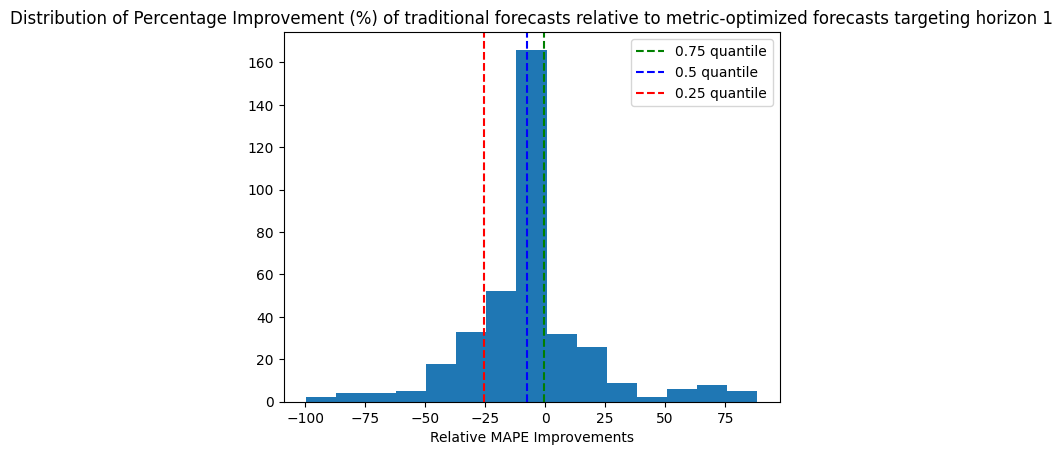

In [26]:
# Average over all time series.
k_step_ahead = 1
perc_improvements = []
for specific_id in id_to_forecast_ensembles:
    true_outcomes = id_to_metrics[specific_id]["default_validate"]["true_outcome"][k_step_ahead-1:k_step_ahead-24]
    one_step_forecasts_default = id_to_forecast_ensembles[specific_id]["default"].numpy()[:,k_step_ahead-1,0]
    one_step_forecasts_custom = id_to_forecast_ensembles[specific_id]["custom"].numpy()[:,k_step_ahead-1,0]
    mape_default = (abs(one_step_forecasts_default - true_outcomes) / true_outcomes).mean()
    mape_custom = (abs(one_step_forecasts_custom - true_outcomes) / true_outcomes).mean()
    perc_improvement = (mape_default - mape_custom) / mape_default * 100
    perc_improvements.append(perc_improvement)
perc_improvements = pd.Series(perc_improvements)
# Visualize distribution.
plt.hist(perc_improvements[abs(perc_improvements) < 100], bins = 15)
plt.axvline(x=perc_improvements.quantile(0.75), color='g', linestyle='--', label='0.75 quantile')
plt.axvline(x=perc_improvements.quantile(0.5), color='b', linestyle='--', label='0.5 quantile')
plt.axvline(x=perc_improvements.quantile(0.25), color='r', linestyle='--', label='0.25 quantile')
plt.legend()
plt.xlabel("Relative MAPE Improvements")
plt.title(f"Distribution of Percentage Improvement (%) of traditional forecasts relative to metric-optimized forecasts targeting horizon {k_step_ahead}")
plt.show()

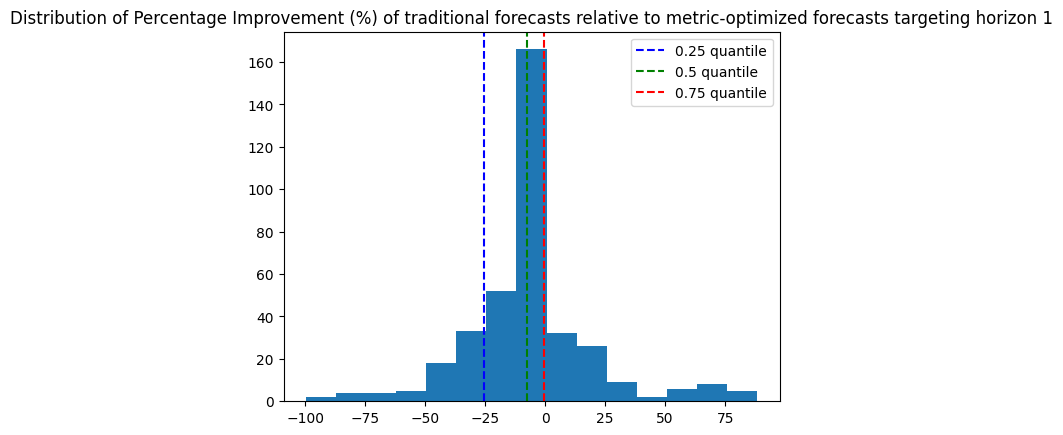

In [27]:
# Average over all time series.
k_step_ahead = 1
perc_improvements = []
for specific_id in id_to_forecast_ensembles:
    true_outcomes = id_to_metrics[specific_id]["default_validate"]["true_outcome"][k_step_ahead-1:k_step_ahead-24]
    one_step_forecasts_default = id_to_forecast_ensembles[specific_id]["default"].numpy()[:,k_step_ahead-1,0]
    one_step_forecasts_custom = id_to_forecast_ensembles[specific_id]["custom"].numpy()[:,k_step_ahead-1,0]
    mape_default = (abs(one_step_forecasts_default - true_outcomes) / true_outcomes).mean()
    mape_custom = (abs(one_step_forecasts_custom - true_outcomes) / true_outcomes).mean()
    perc_improvement = (mape_default - mape_custom) / mape_default * 100
    perc_improvements.append(perc_improvement)
perc_improvements = pd.Series(perc_improvements)
# Visualize distribution.
plt.hist(perc_improvements[abs(perc_improvements) < 100], bins = 15)
# Plot quantile lines and add labels
quantiles = [0.25, 0.5, 0.75]
colors = ['blue', 'green', 'red']
for q, color in zip(quantiles, colors):
    q_value = perc_improvements.quantile(q)
    plt.axvline(x=q_value, color=color, linestyle='--', label=f'{q} quantile')
    # plt.text(q_value, plt.ylim()[1] * 0.95, f'Q{q}\n{q_value:.1f}%', 
    #          ha='center', va='top', color=color, fontweight='bold')
plt.legend()
plt.title(f"Distribution of Percentage Improvement (%) of traditional forecasts relative to metric-optimized forecasts targeting horizon {k_step_ahead}")
plt.show()

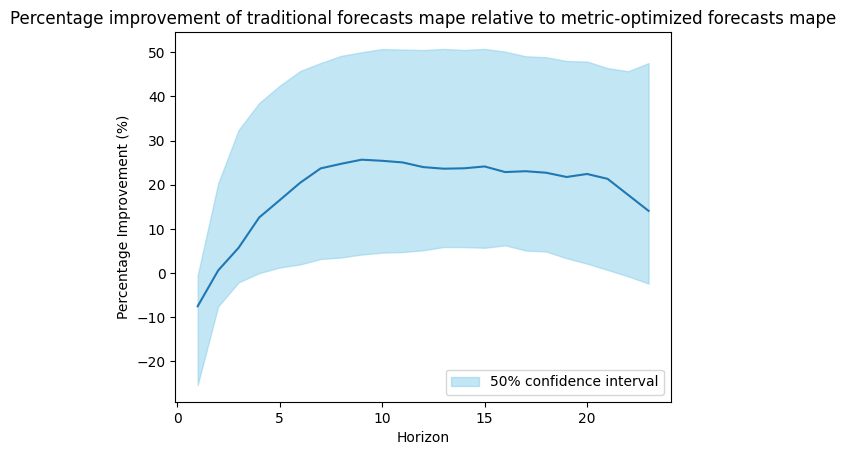

In [28]:
# Plot percentage improvement as a function of horizon.
horizon_to_mape_improvement_median = {}
horizon_to_mape_improvement_75_quantile = {}
horizon_to_mape_improvement_25_quantile = {}
for k_step_ahead in range(1, 24):
    perc_improvements = []
    for specific_id in id_to_forecast_ensembles:
        true_outcomes = id_to_metrics[specific_id]["default_validate"]["true_outcome"][k_step_ahead-1:][:k_step_ahead-24]
        one_step_forecasts_default = id_to_forecast_ensembles[specific_id]["default"].numpy()[:,k_step_ahead-1,0]
        one_step_forecasts_custom = id_to_forecast_ensembles[specific_id]["custom"].numpy()[:,k_step_ahead-1,0]
        mape_default = (abs(one_step_forecasts_default - true_outcomes) / true_outcomes).mean()
        mape_custom = (abs(one_step_forecasts_custom - true_outcomes) / true_outcomes).mean()
        perc_improvement = (
            (mape_default - mape_custom) / mape_default
        )
        perc_improvements.append(perc_improvement)
    perc_improvements = pd.Series(perc_improvements)
    horizon_to_mape_improvement_median[k_step_ahead] = perc_improvements.median() * 100
    horizon_to_mape_improvement_75_quantile[k_step_ahead] = perc_improvements.quantile(0.75) * 100
    horizon_to_mape_improvement_25_quantile[k_step_ahead] = perc_improvements.quantile(0.25) * 100
horizon_to_mape_improvement_median = pd.Series(horizon_to_mape_improvement_median)
horizon_to_mape_improvement_75_quantile = pd.Series(horizon_to_mape_improvement_75_quantile)
horizon_to_mape_improvement_25_quantile = pd.Series(horizon_to_mape_improvement_25_quantile)
horizon_to_mape_improvement_median.plot(title="Percentage improvement of traditional forecasts mape relative to metric-optimized forecasts mape")
plt.fill_between(
    horizon_to_mape_improvement_25_quantile.index, 
    horizon_to_mape_improvement_25_quantile, 
    horizon_to_mape_improvement_75_quantile, 
    color='skyblue', 
    alpha=0.5,
    label = "50% confidence interval"
)
plt.xlabel("Horizon")
plt.ylabel("Percentage Improvement (%)")
plt.legend()
plt.show()

<a name='visualizations'></a>
# Visualizations

In [29]:
# For plotting vertical stability.
def examine_vertical_stability_for_given_target_time(
    forecast_ensemble_default, forecast_ensemble_custom, k
):
    vertical_forecast_default = anti_diagonal(
        forecast_ensemble_default, k
    ).numpy()
    vertical_forecast_custom = anti_diagonal(forecast_ensemble_custom, k).numpy()
    comparison = pd.DataFrame(
        {"default": vertical_forecast_default, "custom": vertical_forecast_custom}
    )
    return comparison

<a name='tabular-view'></a>
## Tabular View

In [30]:
# Generate custom metric statistics on out-of-sample test sets.
validate_cols = [col for col in loss_df.columns if col[-8:] == "validate"]
loss_df[validate_cols].describe()

,loss_default_validate,acc_default_validate,stb_default_validate,loss_custom_validate,acc_custom_validate,stb_custom_validate,loss_impr_validate,acc_impr_validate,stb_impr_validate
count,411.000000,411.000000,411.000000,411.000000,411.000000,411.000000,411.000000,411.000000,404.000000
mean,2753.050563,2499.691030,506.719066,1069.661659,983.826937,171.669444,9.284343,3.326546,52.558112
std,18535.930378,17024.740585,3028.106372,3601.031554,3264.296893,685.922249,40.236164,46.192412,30.208960
min,0.079827,0.077347,0.000000,0.076381,0.075991,0.000000,-438.799318,-550.644616,-108.044841
25%,0.256658,0.221997,0.070336,0.243893,0.219904,0.047225,2.376119,-2.081283,27.060834
50%,81.300823,73.437201,15.005978,70.218388,69.116931,2.297612,7.944203,3.181906,49.998281
75%,645.890066,578.561078,141.288006,531.167626,488.326165,45.091118,17.725870,11.093352,81.007070
max,277506.273365,255060.400928,44891.744876,40657.035878,36476.119910,8361.831935,85.349147,86.031430,99.999942


In [31]:
# Generate one-step-ahead MAPE statistics.
k_step_ahead = 1
mapes_default = {}
mapes_custom = {}
relative_improvements = {}
for specific_id in id_to_forecast_ensembles:
    true_outcomes = id_to_metrics[specific_id]["default_validate"]["true_outcome"][k_step_ahead-1:k_step_ahead-24]
    one_step_forecasts_default = id_to_forecast_ensembles[specific_id]["default"].numpy()[:,k_step_ahead-1,0]
    one_step_forecasts_custom = id_to_forecast_ensembles[specific_id]["custom"].numpy()[:,k_step_ahead-1,0]
    mape_default = (abs(one_step_forecasts_default - true_outcomes) / true_outcomes).mean()
    mapes_default[specific_id] = mape_default
    mape_custom = (abs(one_step_forecasts_custom - true_outcomes) / true_outcomes).mean()
    mapes_custom[specific_id] = mape_custom
    relative_improvement = (mape_default - mape_custom) / mape_default * 100
    relative_improvements[specific_id] = relative_improvement
mape_df = pd.concat(
    [pd.Series(mapes_default), pd.Series(mapes_custom), pd.Series(relative_improvements)],
    keys = ["mape_default", "mape_custom", "relative_improvement"],
    axis = 1,
)
mape_df.describe()

,mape_default,mape_custom,relative_improvement
count,411.000000,411.000000,411.000000
mean,0.158438,0.120023,-26.598643
std,0.421279,0.166240,82.520395
min,0.000520,0.000380,-820.075959
25%,0.002489,0.002794,-25.379939
50%,0.018542,0.032165,-7.545825
75%,0.205548,0.212928,-0.566681
max,5.957387,0.765319,88.258638
